In [1]:
!pip install -q -U transformers accelerate

import os
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 12.9 MB/s eta 0:00:00
device: cuda


In [2]:
MODEL_NAME = "gpt2-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(model.config.n_layer, "layers,", model.config.n_embd, "hidden dim")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

36 layers, 1280 hidden dim


In [3]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)


In [4]:
@torch.no_grad()
def logit_lens(model, hidden_states, tokenizer, top_k=5, position=-1):
    """hidden_states: tuple of (1, seq_len, hidden_dim) tensors, length n_layer+1.
    Returns: list of length n_layer+1; each entry is a list of top_k (token_str, prob) pairs
    for `position` in that layer's hidden state, decoded through the model's own unembedding.
    """
    ln_f = model.transformer.ln_f
    lm_head = model.lm_head
    results = []
    for i, layer_hidden in enumerate(hidden_states):
        h = layer_hidden[0, position, :]
        if i < len(hidden_states) - 1:
            h = ln_f(h)
        logits = lm_head(h)
        probs = torch.softmax(logits, dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        results.append([
            (tokenizer.decode([tid]), float(p))
            for tid, p in zip(top_ids.tolist(), top_probs.tolist())
        ])

    return results

In [5]:
def print_lens(results):
    for i, layer_result in enumerate(results):
        label = "embed" if i == 0 else f"layer {i}"
        top1_tok, top1_p = layer_result[0]
        others = ", ".join(f"{t!r}:{p:.2f}" for t, p in layer_result[1:])
        print(f"{label:>9}  top1={top1_tok!r} ({top1_p:.2f})   next: {others}")

In [6]:
prompt = "The Eiffel Tower is located in the city of"
inputs = tokenizer(prompt, return_tensors="pt").to(device)
outputs = model(**inputs, output_hidden_states=True)

results = logit_lens(model, outputs.hidden_states, tokenizer)
print_lens(results)

    embed  top1=' of' (1.00)   next: ' Of':0.00, ' in':0.00, ' that':0.00, ' with':0.00
  layer 1  top1=' the' (0.14)   next: ' exit':0.03, ' Pittsburgh':0.02, ' all':0.01, ' "':0.01
  layer 2  top1=' the' (0.04)   next: ' all':0.01, ' "':0.01, ' a':0.01, ' his':0.00
  layer 3  top1=' the' (0.03)   next: ' a':0.01, ' all':0.01, ' "':0.00, ' his':0.00
  layer 4  top1=' the' (0.02)   next: ' a':0.01, ' "':0.01, ' all':0.00, ' course':0.00
  layer 5  top1=' the' (0.02)   next: ' course':0.01, ' a':0.01, ' "':0.00, ' all':0.00
  layer 6  top1=' the' (0.02)   next: ' course':0.01, ' a':0.01, ' "':0.00, ' San':0.00
  layer 7  top1=' the' (0.02)   next: ' course':0.01, ' San':0.01, ' "':0.00, ' late':0.00
  layer 8  top1=' the' (0.02)   next: ' course':0.01, ' North':0.01, ' West':0.01, ' San':0.01
  layer 9  top1=' West' (0.01)   next: ' San':0.01, ' North':0.01, ' King':0.01, ' summer':0.01
 layer 10  top1=' San' (0.03)   next: ' King':0.02, ' West':0.01, ' South':0.01, ' North':0.01
 layer

In [7]:
prompt2 = " Zephyr Quilbo river mountain Zephyr"
inputs2 = tokenizer(prompt2, return_tensors="pt").to(device)
outputs2 = model(**inputs2, output_hidden_states=True)

results2 = logit_lens(model, outputs2.hidden_states, tokenizer)
print_lens(results2)

print("\ntokenization check:", tokenizer.convert_ids_to_tokens(inputs2["input_ids"][0]))

    embed  top1='yr' (1.00)   next: 'yrs':0.00, 'YR':0.00, 'yre':0.00, 'yd':0.00
  layer 1  top1='yr' (1.00)   next: 'yrs':0.00, 'hy':0.00, 'ulia':0.00, 'ror':0.00
  layer 2  top1='yr' (0.71)   next: 'idium':0.02, 'hy':0.02, 'rha':0.02, 'rh':0.01
  layer 3  top1='yr' (0.18)   next: 'rha':0.10, 'idium':0.04, 'hy':0.03, 'rh':0.02
  layer 4  top1='rha' (0.17)   next: 'yr':0.10, 'hy':0.08, 'idium':0.04, 'tle':0.02
  layer 5  top1='rha' (0.12)   next: 'idium':0.05, 'hy':0.04, 'r':0.03, 'rh':0.02
  layer 6  top1='r' (0.04)   next: 'hy':0.04, 'rha':0.03, 'tle':0.03, 'rr':0.03
  layer 7  top1='r' (0.05)   next: 'idium':0.04, 'ra':0.03, 'rr':0.03, 'idia':0.02
  layer 8  top1='r' (0.06)   next: 'rh':0.03, 'hy':0.03, 'ra':0.02, 'tle':0.02
  layer 9  top1='rh' (0.04)   next: 'r':0.03, 'b':0.02, 'idia':0.02, 'ra':0.02
 layer 10  top1='tle' (0.04)   next: 'r':0.04, 'rh':0.03, 'ion':0.03, 'b':0.02
 layer 11  top1='r' (0.03)   next: 'ion':0.02, 'tle':0.01, 'idia':0.01, 'rh':0.01
 layer 12  top1='ion' 

In [8]:
last_layer_lens_logits = model.lm_head((outputs.hidden_states[-1][0, -1, :]))
real_logits = outputs.logits[0, -1, :]

max_diff = (last_layer_lens_logits - real_logits).abs().max().item()
print("Max absolute difference between real output logits and final logit lens logits:", max_diff)
assert max_diff < 1e-3, "Error in logit lens implementation."

Max absolute difference between real output logits and final logit lens logits: 1.1444091796875e-05


In [9]:
@torch.no_grad()
def token_prob_by_layer(model, hidden_states, tokenizer, target_token, position=-1):
    ln_f = model.transformer.ln_f
    lm_head = model.lm_head
    target_id = tokenizer.encode(target_token)[0]
    probs = []
    for i, layer_hidden in enumerate(hidden_states):
        h = layer_hidden[0, position, :]
        if i < len(hidden_states) - 1:
            h = ln_f(h)
        logits = lm_head(h)
        p = torch.softmax(logits, dim=-1)[target_id]
        probs.append(float(p))
    return probs

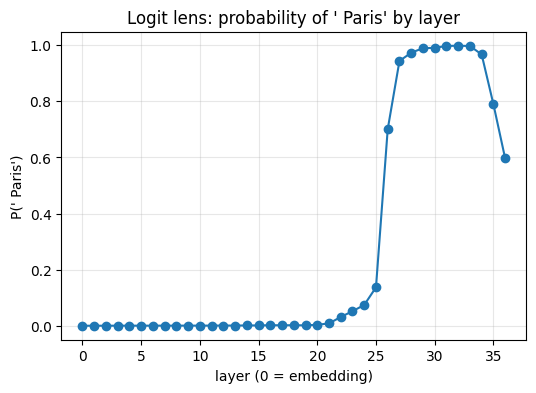

In [10]:
probs_paris = token_prob_by_layer(model, outputs.hidden_states, tokenizer, " Paris")

plt.figure(figsize=(6, 4))
plt.plot(range(len(probs_paris)), probs_paris, marker="o")
plt.xlabel("layer (0 = embedding)")
plt.ylabel("P(' Paris')")
plt.title("Logit lens: probability of ' Paris' by layer")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/logit_lens_paris.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
os.makedirs("/kaggle/working/cache", exist_ok=True)

torch.save(
    {
        "prompt": prompt,
        "lens_results": results,
        "prompt2": prompt2,
        "lens_results2": results2,
        "probs_paris": probs_paris,
    },
    "/kaggle/working/cache/day1_gpt2_sanity.pt",
)
print("saved.")

saved.
